# Music Rationale RLHF

Fine-tuning `Qwen/Qwen2.5-1.5B-Instruct` to generate better explanations for why someone would enjoy a recommended song, using human preference data and RLHF.

Pipeline: Preference Data (100 pairs) -> Reward Model (Bradley-Terry) -> SFT Baseline (LoRA) -> PPO -> Overoptimization Analysis

Running on A100 with BF16.

> Challenge 2: Taming the Language Model

## 0. Setup

In [ ]:
!pip install trl transformers datasets accelerate peft torch \
             scikit-learn matplotlib seaborn pandas numpy -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 531.0/531.0 kB 10.4 MB/s eta 0:00:00


In [ ]:
!pip install trl==0.11.4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 316.6/316.6 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.4/183.4 kB 22.6 MB/s eta 0:00:00
  Attempting uninstall: trl
    Found existing installation: trl 0.29.1
    Uninstalling trl-0.29.1:
      Successfully uninstalled trl-0.29.1


In [ ]:
import json, random, warnings, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import defaultdict, Counter

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from datasets import Dataset
from transformers import (
    AutoTokenizer, AutoModelForCausalLM, AutoModelForSequenceClassification,
    TrainingArguments, Trainer
)
from trl import PPOTrainer, PPOConfig, AutoModelForCausalLMWithValueHead
from peft import LoraConfig, get_peft_model, TaskType

warnings.filterwarnings('ignore')
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}, PyTorch: {torch.__version__}')

Device: cuda, PyTorch: 2.10.0+cu128


## 1. Load and Explore Preference Data

In [ ]:
with open('music_rlhf_preferences.json', 'r') as f:
    raw_data = json.load(f)

df = pd.DataFrame(raw_data)
print(f'Total examples: {len(df)}')
print(df['preference'].value_counts())
df.head(3)

Total examples: 100
preference
B      52
A      30
tie    18
Name: count, dtype: int64


,id,input_song,rationale_A,rationale_B,preference
0,1,Bohemian Rhapsody by Queen,You might like 'Stairway to Heaven' by Led Zep...,This song has great vibes and energy that you'...,A
1,2,Blinding Lights by The Weeknd,Try 'Take On Me' by a-ha — both tracks lean in...,'Save Your Tears' by The Weeknd is a great son...,A
2,3,Redbone by Childish Gambino,This is a cool song and there are many others ...,'Stay With Me' by Sam Smith shares Redbone's s...,B


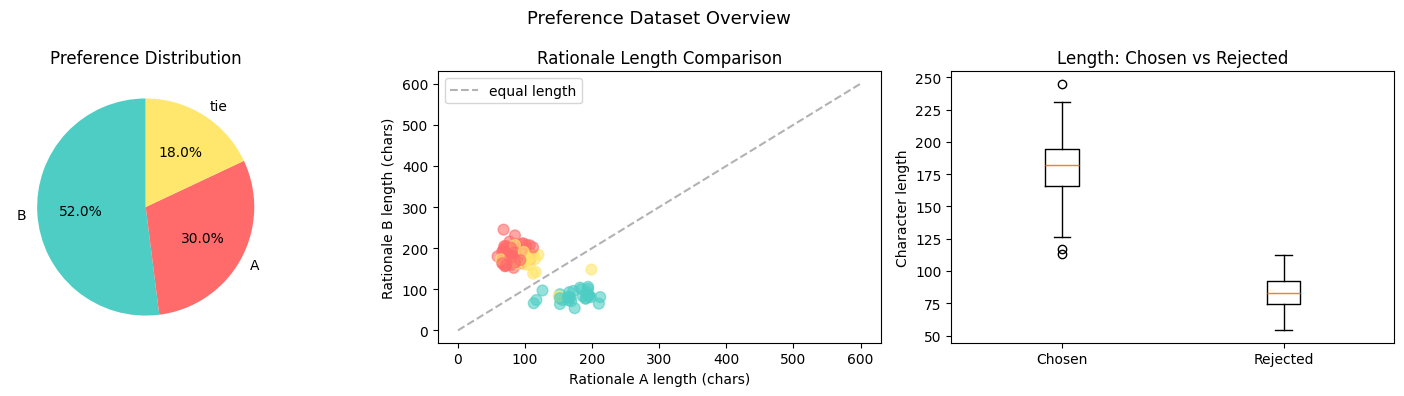

Avg chosen length: 181 chars
Avg rejected length: 83 chars


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Preference Dataset Overview', fontsize=13)

pref_counts = df['preference'].value_counts()
axes[0].pie(pref_counts.values, labels=pref_counts.index,
            colors=['#4ECDC4', '#FF6B6B', '#FFE66D'], autopct='%1.1f%%', startangle=90)
axes[0].set_title('Preference Distribution')

df['len_A'] = df['rationale_A'].str.len()
df['len_B'] = df['rationale_B'].str.len()
axes[1].scatter(df['len_A'], df['len_B'],
                c=df['preference'].map({'A': '#4ECDC4', 'B': '#FF6B6B', 'tie': '#FFE66D'}),
                alpha=0.6, s=60)
axes[1].plot([0, 600], [0, 600], 'k--', alpha=0.3, label='equal length')
axes[1].set_xlabel('Rationale A length (chars)')
axes[1].set_ylabel('Rationale B length (chars)')
axes[1].set_title('Rationale Length Comparison')
axes[1].legend()

chosen_lens, rejected_lens = [], []
for _, row in df.iterrows():
    if row['preference'] == 'A':
        chosen_lens.append(row['len_A'])
        rejected_lens.append(row['len_B'])
    elif row['preference'] == 'B':
        chosen_lens.append(row['len_B'])
        rejected_lens.append(row['len_A'])

axes[2].boxplot([chosen_lens, rejected_lens], labels=['Chosen', 'Rejected'])
axes[2].set_ylabel('Character length')
axes[2].set_title('Length: Chosen vs Rejected')

plt.tight_layout()
plt.savefig('dataset_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Avg chosen length: {np.mean(chosen_lens):.0f} chars')
print(f'Avg rejected length: {np.mean(rejected_lens):.0f} chars')

## 2. Data Preprocessing

Format data for reward model training (chosen/rejected pairs, ties excluded) and PPO (query prompts).

In [ ]:
BASE_MODEL_NAME = 'Qwen/Qwen2.5-1.5B-Instruct'

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_NAME, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = 'left'

SYSTEM_PROMPT = (
    'You are a music expert. Given a song the user loves, recommend one song '
    'and explain in 2-3 sentences exactly why they will enjoy it. '
    'Be specific: reference production style, structural elements, emotional texture, '
    'or musical genealogy. Avoid generic phrases like great vibes or similar energy.'
)

def make_prompt(input_song):
    messages = [
        {'role': 'system', 'content': SYSTEM_PROMPT},
        {'role': 'user', 'content': f"I love '{input_song}'. What should I listen to next and why?"}
    ]
    return tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

rm_examples = []
for row in raw_data:
    if row['preference'] == 'tie':
        continue
    prompt = make_prompt(row['input_song'])
    if row['preference'] == 'A':
        chosen, rejected = row['rationale_A'], row['rationale_B']
    else:
        chosen, rejected = row['rationale_B'], row['rationale_A']
    rm_examples.append({'prompt': prompt, 'chosen': chosen, 'rejected': rejected})

random.shuffle(rm_examples)
split = int(0.85 * len(rm_examples))
rm_train = rm_examples[:split]
rm_eval = rm_examples[split:]

ppo_queries = [make_prompt(row['input_song']) for row in raw_data]

print(f'Reward model: {len(rm_train)} train, {len(rm_eval)} eval')
print(f'Ties excluded: {sum(1 for r in raw_data if r["preference"]=="tie")}')
print(f'PPO queries: {len(ppo_queries)}')

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Reward model: 69 train, 13 eval
Ties excluded: 18
PPO queries: 100


In [ ]:
def tokenize_rm(examples, tokenizer, max_length=256):
    chosen_full = [p + c for p, c in zip(examples['prompt'], examples['chosen'])]
    rejected_full = [p + r for p, r in zip(examples['prompt'], examples['rejected'])]

    tok_chosen = tokenizer(chosen_full, truncation=True, max_length=max_length,
                           padding='max_length', return_tensors='pt')
    tok_rejected = tokenizer(rejected_full, truncation=True, max_length=max_length,
                              padding='max_length', return_tensors='pt')
    return {
        'input_ids_chosen': tok_chosen['input_ids'],
        'attention_mask_chosen': tok_chosen['attention_mask'],
        'input_ids_rejected': tok_rejected['input_ids'],
        'attention_mask_rejected': tok_rejected['attention_mask'],
    }

train_ds = Dataset.from_list(rm_train)
eval_ds = Dataset.from_list(rm_eval)

train_ds = train_ds.map(lambda x: tokenize_rm(x, tokenizer), batched=True,
                        remove_columns=['prompt', 'chosen', 'rejected'])
eval_ds = eval_ds.map(lambda x: tokenize_rm(x, tokenizer), batched=True,
                       remove_columns=['prompt', 'chosen', 'rejected'])
train_ds.set_format('torch')
eval_ds.set_format('torch')

Map:   0%|          | 0/69 [00:00<?, ? examples/s]

Map:   0%|          | 0/13 [00:00<?, ? examples/s]

## 3. Reward Model

Bradley-Terry reward model: learns `score(chosen) > score(rejected)` from pairwise preferences.

Loss: `-log sigmoid(r_chosen - r_rejected)`

In [ ]:
class BradleyTerryRewardModel(nn.Module):
    def __init__(self, model_name):
        super().__init__()
        self.backbone = AutoModelForSequenceClassification.from_pretrained(
            model_name, num_labels=1, ignore_mismatched_sizes=True,
            torch_dtype=torch.bfloat16, trust_remote_code=True,
        )
        self.backbone.config.pad_token_id = tokenizer.pad_token_id

    def forward(self, input_ids, attention_mask):
        return self.backbone(
            input_ids=input_ids, attention_mask=attention_mask
        ).logits.squeeze(-1).float()

    def compute_loss(self, batch):
        r_chosen = self(batch['input_ids_chosen'].to(DEVICE),
                        batch['attention_mask_chosen'].to(DEVICE))
        r_rejected = self(batch['input_ids_rejected'].to(DEVICE),
                          batch['attention_mask_rejected'].to(DEVICE))
        loss = -torch.nn.functional.logsigmoid(r_chosen - r_rejected).mean()
        acc = (r_chosen > r_rejected).float().mean()
        return loss, acc, r_chosen.detach(), r_rejected.detach()

reward_model = BradleyTerryRewardModel(BASE_MODEL_NAME).to(DEVICE)
print(f'Reward model params: {sum(p.numel() for p in reward_model.parameters()):,}')

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Qwen2ForSequenceClassification LOAD REPORT from: Qwen/Qwen2.5-1.5B-Instruct
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Reward model params: 1,543,715,840


In [ ]:
RM_EPOCHS = 5
RM_LR = 2e-5
RM_BATCH = 16

optimizer = torch.optim.AdamW(reward_model.parameters(), lr=RM_LR, weight_decay=0.01)
train_loader = DataLoader(train_ds, batch_size=RM_BATCH, shuffle=True)
eval_loader = DataLoader(eval_ds, batch_size=RM_BATCH)

rm_history = defaultdict(list)

for epoch in range(RM_EPOCHS):
    reward_model.train()
    epoch_loss, epoch_acc = [], []
    for batch in train_loader:
        optimizer.zero_grad()
        loss, acc, _, _ = reward_model.compute_loss(batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(reward_model.parameters(), 1.0)
        optimizer.step()
        epoch_loss.append(loss.item())
        epoch_acc.append(acc.item())

    reward_model.eval()
    eval_loss, eval_acc = [], []
    with torch.no_grad():
        for batch in eval_loader:
            loss, acc, _, _ = reward_model.compute_loss(batch)
            eval_loss.append(loss.item())
            eval_acc.append(acc.item())

    rm_history['train_loss'].append(np.mean(epoch_loss))
    rm_history['train_acc'].append(np.mean(epoch_acc))
    rm_history['eval_loss'].append(np.mean(eval_loss))
    rm_history['eval_acc'].append(np.mean(eval_acc))

    print(f'Epoch {epoch+1}/{RM_EPOCHS} | '
          f'Train Loss: {rm_history["train_loss"][-1]:.4f} Acc: {rm_history["train_acc"][-1]:.3f} | '
          f'Eval Loss: {rm_history["eval_loss"][-1]:.4f} Acc: {rm_history["eval_acc"][-1]:.3f}')

torch.save(reward_model.state_dict(), 'reward_model.pt')

Epoch 1/5 | Train Loss: 0.1704 Acc: 0.925 | Eval Loss: 0.0000 Acc: 1.000
Epoch 2/5 | Train Loss: 0.0000 Acc: 1.000 | Eval Loss: 0.0000 Acc: 1.000
Epoch 3/5 | Train Loss: 0.0000 Acc: 1.000 | Eval Loss: 0.0000 Acc: 1.000
Epoch 4/5 | Train Loss: 0.0000 Acc: 1.000 | Eval Loss: 0.0000 Acc: 1.000
Epoch 5/5 | Train Loss: 0.0000 Acc: 1.000 | Eval Loss: 0.0000 Acc: 1.000


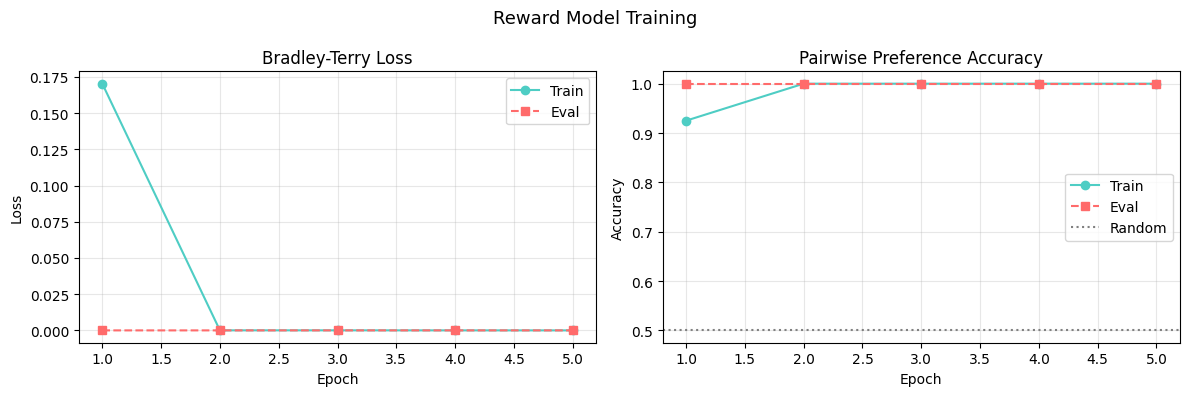

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Reward Model Training', fontsize=13)

epochs = range(1, RM_EPOCHS + 1)
axes[0].plot(epochs, rm_history['train_loss'], 'o-', label='Train', color='#4ECDC4')
axes[0].plot(epochs, rm_history['eval_loss'], 's--', label='Eval', color='#FF6B6B')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Bradley-Terry Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs, rm_history['train_acc'], 'o-', label='Train', color='#4ECDC4')
axes[1].plot(epochs, rm_history['eval_acc'], 's--', label='Eval', color='#FF6B6B')
axes[1].axhline(0.5, color='gray', linestyle=':', label='Random')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title('Pairwise Preference Accuracy'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('reward_model_training.png', dpi=150, bbox_inches='tight')
plt.show()

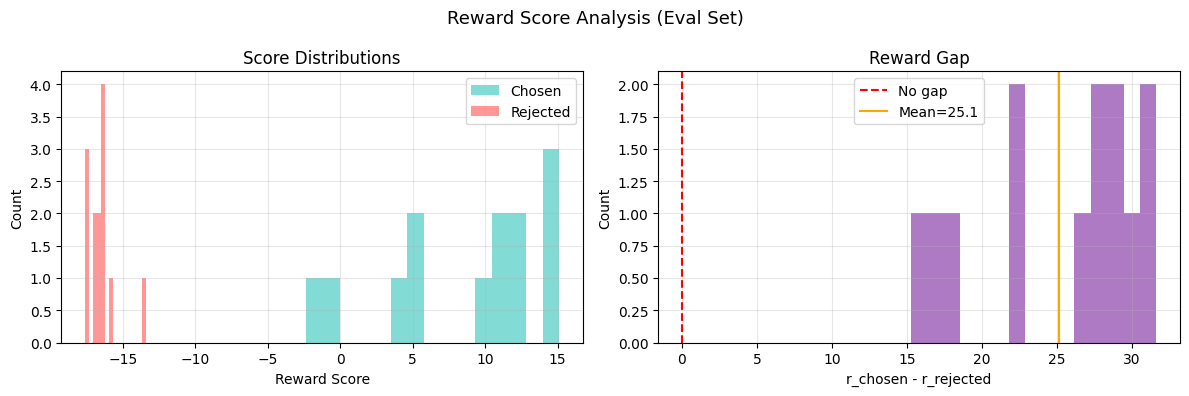

Mean chosen reward: 8.6163
Mean rejected reward: -16.5337
Mean gap: 25.1499
Correctly ranked: 100.0%


In [ ]:
reward_model.eval()
all_r_chosen, all_r_rejected = [], []
with torch.no_grad():
    for batch in eval_loader:
        _, _, rc, rr = reward_model.compute_loss(batch)
        all_r_chosen.extend(rc.cpu().numpy())
        all_r_rejected.extend(rr.cpu().numpy())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Reward Score Analysis (Eval Set)', fontsize=13)

axes[0].hist(all_r_chosen, bins=15, alpha=0.7, label='Chosen', color='#4ECDC4')
axes[0].hist(all_r_rejected, bins=15, alpha=0.7, label='Rejected', color='#FF6B6B')
axes[0].set_xlabel('Reward Score'); axes[0].set_ylabel('Count')
axes[0].set_title('Score Distributions'); axes[0].legend(); axes[0].grid(alpha=0.3)

gaps = [c - r for c, r in zip(all_r_chosen, all_r_rejected)]
axes[1].hist(gaps, bins=15, color='#9B59B6', alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--', label='No gap')
axes[1].axvline(np.mean(gaps), color='orange', linestyle='-', label=f'Mean={np.mean(gaps):.1f}')
axes[1].set_xlabel('r_chosen - r_rejected'); axes[1].set_ylabel('Count')
axes[1].set_title('Reward Gap'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('reward_gap_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Mean chosen reward: {np.mean(all_r_chosen):.4f}')
print(f'Mean rejected reward: {np.mean(all_r_rejected):.4f}')
print(f'Mean gap: {np.mean(gaps):.4f}')
print(f'Correctly ranked: {np.mean([g > 0 for g in gaps]):.1%}')

## 4. SFT Baseline

LoRA fine-tuning on chosen rationales so the model learns the task format before PPO refines quality.

Using more epochs than typical since we only have 100 examples and need the model to actually pick up the output format.

In [ ]:
tokenizer.padding_side = 'right'

sft_examples = []
for row in raw_data:
    prompt = make_prompt(row['input_song'])
    if row['preference'] == 'A':
        completion = row['rationale_A']
    elif row['preference'] == 'B':
        completion = row['rationale_B']
    else:
        completion = row['rationale_A']
    sft_examples.append({'prompt': prompt, 'completion': completion})

def tokenize_sft(examples):
    all_input_ids = []
    all_attention_mask = []
    all_labels = []
    for prompt, completion in zip(examples['prompt'], examples['completion']):
        full_text = prompt + completion + tokenizer.eos_token
        prompt_ids = tokenizer(prompt, add_special_tokens=False)['input_ids']
        prompt_len = len(prompt_ids)
        tok = tokenizer(full_text, truncation=True, max_length=512, padding='max_length')
        labels = list(tok['input_ids'])
        for j in range(prompt_len):
            labels[j] = -100
        for j in range(len(labels)):
            if tok['attention_mask'][j] == 0:
                labels[j] = -100
        all_input_ids.append(tok['input_ids'])
        all_attention_mask.append(tok['attention_mask'])
        all_labels.append(labels)
    return {'input_ids': all_input_ids, 'attention_mask': all_attention_mask, 'labels': all_labels}

sft_ds = Dataset.from_list(sft_examples)
sft_ds = sft_ds.map(tokenize_sft, batched=True, remove_columns=['prompt', 'completion'])
sft_ds.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])

n_completion_tokens = sum(1 for l in sft_ds[0]['labels'].tolist() if l != -100)
print(f'SFT examples: {len(sft_ds)}')
print(f'Completion tokens in first example: {n_completion_tokens}')

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

SFT examples: 100
Completion tokens in first example: 36


In [ ]:
sft_base = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL_NAME, torch_dtype=torch.bfloat16,
    device_map='auto', trust_remote_code=True,
)

lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=16, lora_alpha=32,
    target_modules=['q_proj', 'k_proj', 'v_proj', 'o_proj'],
    lora_dropout=0.05, bias='none'
)
sft_model = get_peft_model(sft_base, lora_config)
sft_model.print_trainable_parameters()

sft_args = TrainingArguments(
    output_dir='./sft_output',
    num_train_epochs=15,
    per_device_train_batch_size=8,
    gradient_accumulation_steps=2,
    learning_rate=5e-4,
    warmup_steps=20,
    logging_steps=10,
    save_strategy='no',
    report_to='none',
    bf16=True, fp16=False,
    gradient_checkpointing=True,
    optim='adamw_torch_fused',
)

sft_trainer = Trainer(
    model=sft_model,
    args=sft_args,
    train_dataset=sft_ds,
)
sft_trainer.train()

sft_model = sft_model.merge_and_unload()
sft_model.save_pretrained('./sft_merged')
tokenizer.save_pretrained('./sft_merged')
print('SFT model saved to ./sft_merged')

tokenizer.padding_side = 'left'

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

trainable params: 4,358,144 || all params: 1,548,072,448 || trainable%: 0.2815


Step,Training Loss
10,3.311489
20,2.636345
30,2.121836
40,1.685930
50,1.231479
60,0.823552
70,0.547892
80,0.303446
90,0.196627
100,0.129242


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

SFT model saved to ./sft_merged


In [ ]:
def generate_rationale(model, tokenizer, song, max_new_tokens=120):
    prompt = make_prompt(song)
    inputs = tokenizer(prompt, return_tensors='pt').to(DEVICE)
    with torch.no_grad():
        output = model.generate(
            **inputs, max_new_tokens=max_new_tokens,
            do_sample=True, temperature=0.8, top_p=0.9,
            pad_token_id=tokenizer.eos_token_id
        )
    generated = tokenizer.decode(output[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)
    return generated.strip()

test_songs = ['Bohemian Rhapsody by Queen', 'Blinding Lights by The Weeknd', 'cardigan by Taylor Swift']
sft_model_device = sft_model.to(DEVICE)

print('SFT Baseline Generations:')
sft_outputs = {}
for song in test_songs:
    gen = generate_rationale(sft_model_device, tokenizer, song)
    sft_outputs[song] = gen
    print(f'\n  {song}')
    print(f'  -> {gen}')

SFT Baseline Generations:


`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.



  Bohemian Rhapsody by Queen
  -> 'ex-\n = 15月球的____ ____
Determine the
B. The following a \n166998月平均平均平均值
D. 另
DLMFASRandy y - 0. 000

# Python
A circle is not present
C. �车轮对
Ech=input("b'Khi i s\n
Nin which the other.
The following is a\frac{pynyline (2. "a=int(input('c# This can we can either of the

  Blinding Lights by The Weeknd
  -> 'Pine
C# How can even if (265月球球系
A car
Cody
答案。
A math

199998888、
Determine the
B-A
import java.io\/\n\\section \frac{p = [1947月的正确．____ is an error: "0. �的单项选择正确的
Determine the first place itself.
The following
CABE. 1.  中国共产党书记。

  cardigan by Taylor Swift
  -> 'FAB0

# -*-
C. The given an increase the number of the following is the
A high that \( \in a 17月平均平均平均值的。 
# How does not the output
Determine what can even more than either.
\section . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . .


## 5. PPO Fine-Tuning

Using the reward model as signal for PPO. Each step: sample queries, generate responses, score with RM, update policy with KL penalty against the SFT reference.

In [ ]:
ppo_model = AutoModelForCausalLMWithValueHead.from_pretrained(
    './sft_merged', torch_dtype=torch.bfloat16, trust_remote_code=True,
)
ppo_ref_model = AutoModelForCausalLMWithValueHead.from_pretrained(
    './sft_merged', torch_dtype=torch.bfloat16, trust_remote_code=True,
)

ppo_config = PPOConfig(
    model_name='./sft_merged',
    learning_rate=1.5e-5,
    batch_size=16, mini_batch_size=4,
    gradient_accumulation_steps=1,
    ppo_epochs=4,
    max_grad_norm=0.5,
    kl_penalty='kl',
    init_kl_coef=0.2,
    adap_kl_ctrl=True,
    target_kl=6.0,
    cliprange=0.2,
    vf_coef=0.1,
    log_with=None,
    remove_unused_columns=False,
)

ppo_trainer = PPOTrainer(
    config=ppo_config, model=ppo_model,
    ref_model=ppo_ref_model, tokenizer=tokenizer,
)
print(f'PPO ready. KL coef: {ppo_config.init_kl_coef}, target KL: {ppo_config.target_kl}')

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

PPO ready. KL coef: 0.2, target KL: 6.0


In [ ]:
generation_kwargs = {
    'max_new_tokens': 100,
    'do_sample': True,
    'temperature': 0.9,
    'top_p': 0.9,
    'pad_token_id': tokenizer.eos_token_id,
}

def get_reward(texts):
    reward_model.eval()
    rewards = []
    for text in texts:
        enc = tokenizer(text, return_tensors='pt', truncation=True,
                        max_length=256, padding='max_length').to(DEVICE)
        with torch.no_grad():
            score = reward_model(enc['input_ids'], enc['attention_mask'])
        rewards.append(score.squeeze().cpu())
    return rewards

def tokenize_query(query):
    return tokenizer(query, return_tensors='pt', truncation=True, max_length=128)['input_ids'].squeeze(0)

tokenized_queries = [tokenize_query(q) for q in ppo_queries]

In [ ]:
PPO_STEPS = 50

ppo_history = {'mean_reward': [], 'kl_div': [], 'ppo_loss': [],
               'response_lengths': [], 'step': []}

print(f'Running PPO for {PPO_STEPS} steps...')

for step in range(PPO_STEPS):
    batch_idxs = random.sample(range(len(tokenized_queries)), ppo_config.batch_size)
    query_tensors = [tokenized_queries[i].to(DEVICE) for i in batch_idxs]
    query_texts = [ppo_queries[i] for i in batch_idxs]

    response_tensors = ppo_trainer.generate(
        query_tensors, return_prompt=False, **generation_kwargs
    )
    response_texts = [tokenizer.decode(r, skip_special_tokens=True) for r in response_tensors]

    full_texts = [q + r for q, r in zip(query_texts, response_texts)]
    rewards = get_reward(full_texts)

    stats = ppo_trainer.step(query_tensors, response_tensors, rewards)

    mean_reward = np.mean([r.item() for r in rewards])
    mean_len = np.mean([len(r) for r in response_tensors])
    kl = stats.get('objective/kl', 0)
    ppo_loss = stats.get('ppo/loss/total', 0)

    ppo_history['mean_reward'].append(mean_reward)
    ppo_history['kl_div'].append(kl)
    ppo_history['ppo_loss'].append(ppo_loss)
    ppo_history['response_lengths'].append(mean_len)
    ppo_history['step'].append(step)

    if step % 10 == 0 or step == PPO_STEPS - 1:
        print(f'Step {step:3d} | reward: {mean_reward:+.4f} | KL: {kl:.4f} | '
              f'loss: {ppo_loss:.4f} | len: {mean_len:.0f}')

print('\nDone.')
ppo_model.save_pretrained('./ppo_model')
tokenizer.save_pretrained('./ppo_model')

Running PPO for 50 steps...
Step   0 | reward: +4.3508 | KL: 0.0000 | loss: 1.5628 | len: 36
Step  10 | reward: +4.6779 | KL: 51.7165 | loss: 0.7735 | len: 37
Step  20 | reward: +9.1250 | KL: 49.9046 | loss: 0.5997 | len: 30
Step  30 | reward: +17.3828 | KL: 71.3121 | loss: 0.2260 | len: 33
Step  40 | reward: +18.1289 | KL: 58.9170 | loss: 0.1256 | len: 28
Step  49 | reward: +18.3242 | KL: 62.3694 | loss: 0.2376 | len: 29

Done.


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./ppo_model/tokenizer_config.json',
 './ppo_model/chat_template.jinja',
 './ppo_model/tokenizer.json')

## 6. PPO Metrics and Qualitative Comparison

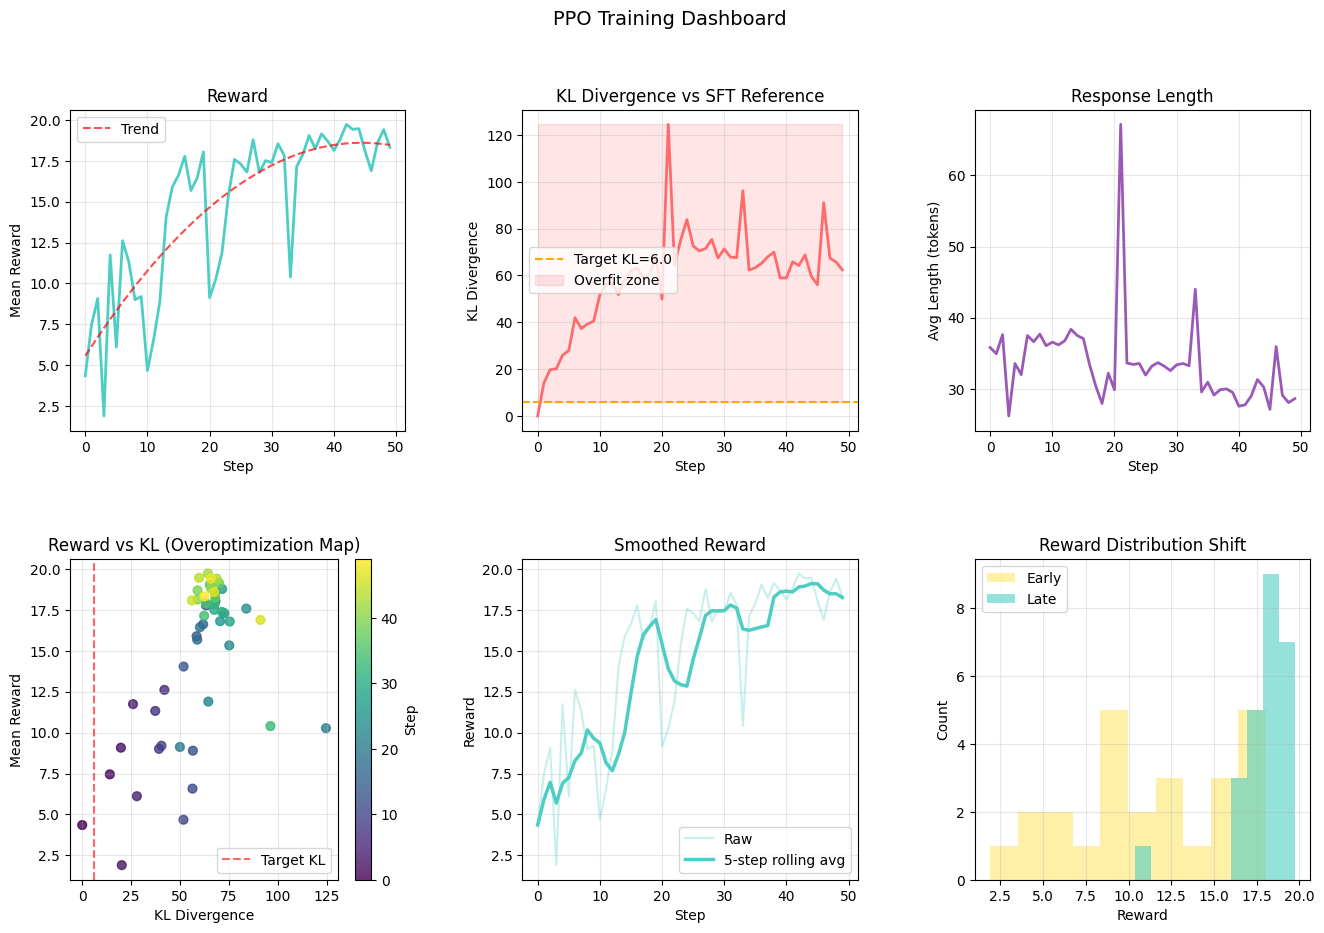

In [ ]:
fig = plt.figure(figsize=(16, 10))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)
fig.suptitle('PPO Training Dashboard', fontsize=14)

steps = ppo_history['step']

ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(steps, ppo_history['mean_reward'], color='#4ECDC4', linewidth=2)
z = np.polyfit(steps, ppo_history['mean_reward'], 2)
ax1.plot(steps, np.poly1d(z)(steps), 'r--', alpha=0.7, label='Trend')
ax1.set_xlabel('Step'); ax1.set_ylabel('Mean Reward')
ax1.set_title('Reward'); ax1.grid(alpha=0.3); ax1.legend()

ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(steps, ppo_history['kl_div'], color='#FF6B6B', linewidth=2)
ax2.axhline(ppo_config.target_kl, color='orange', linestyle='--',
            label=f'Target KL={ppo_config.target_kl}')
ax2.fill_between(steps, ppo_config.target_kl,
                 [max(ppo_history['kl_div'])] * len(steps),
                 alpha=0.1, color='red', label='Overfit zone')
ax2.set_xlabel('Step'); ax2.set_ylabel('KL Divergence')
ax2.set_title('KL Divergence vs SFT Reference'); ax2.grid(alpha=0.3); ax2.legend()

ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(steps, ppo_history['response_lengths'], color='#9B59B6', linewidth=2)
ax3.set_xlabel('Step'); ax3.set_ylabel('Avg Length (tokens)')
ax3.set_title('Response Length'); ax3.grid(alpha=0.3)

ax4 = fig.add_subplot(gs[1, 0])
sc = ax4.scatter(ppo_history['kl_div'], ppo_history['mean_reward'],
                 c=steps, cmap='viridis', s=40, alpha=0.8)
plt.colorbar(sc, ax=ax4, label='Step')
ax4.axvline(ppo_config.target_kl, color='red', linestyle='--', alpha=0.6, label='Target KL')
ax4.set_xlabel('KL Divergence'); ax4.set_ylabel('Mean Reward')
ax4.set_title('Reward vs KL (Overoptimization Map)'); ax4.legend(); ax4.grid(alpha=0.3)

ax5 = fig.add_subplot(gs[1, 1])
rolling = pd.Series(ppo_history['mean_reward']).rolling(5, min_periods=1).mean()
ax5.plot(steps, ppo_history['mean_reward'], alpha=0.3, color='#4ECDC4', label='Raw')
ax5.plot(steps, rolling, color='#4ECDC4', linewidth=2.5, label='5-step rolling avg')
ax5.set_xlabel('Step'); ax5.set_ylabel('Reward')
ax5.set_title('Smoothed Reward'); ax5.legend(); ax5.grid(alpha=0.3)

ax6 = fig.add_subplot(gs[1, 2])
mid = len(ppo_history['mean_reward']) // 2
ax6.hist(ppo_history['mean_reward'][:mid], bins=10, alpha=0.6, color='#FFE66D', label='Early')
ax6.hist(ppo_history['mean_reward'][mid:], bins=10, alpha=0.6, color='#4ECDC4', label='Late')
ax6.set_xlabel('Reward'); ax6.set_ylabel('Count')
ax6.set_title('Reward Distribution Shift'); ax6.legend(); ax6.grid(alpha=0.3)

plt.savefig('ppo_metrics_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
ppo_model_eval = ppo_model.pretrained_model.to(DEVICE)

comparison_songs = [
    'Bohemian Rhapsody by Queen',
    'Blinding Lights by The Weeknd',
    'cardigan by Taylor Swift',
    'Alright by Kendrick Lamar',
    'Clair de Lune by Debussy',
]

ppo_outputs = {}
comparison_data = []

for song in comparison_songs:
    sft_gen = sft_outputs.get(song) or generate_rationale(sft_model_device, tokenizer, song)
    ppo_gen = generate_rationale(ppo_model_eval, tokenizer, song)
    ppo_outputs[song] = ppo_gen

    sft_score = get_reward([make_prompt(song) + sft_gen])[0].item()
    ppo_score = get_reward([make_prompt(song) + ppo_gen])[0].item()

    comparison_data.append({
        'song': song, 'sft_output': sft_gen, 'ppo_output': ppo_gen,
        'sft_reward': sft_score, 'ppo_reward': ppo_score,
        'reward_delta': ppo_score - sft_score
    })

    print(f'{song}')
    print(f'  SFT (r={sft_score:.2f}): {sft_gen[:200]}')
    print(f'  PPO (r={ppo_score:.2f}): {ppo_gen[:200]}')
    print(f'  delta: {ppo_score - sft_score:+.2f}\n')

Bohemian Rhapsody by Queen
  SFT (r=1.80): 'ex-\n = 15月球的____ ____
Determine the
B. The following a \n166998月平均平均平均值
D. 另
DLMFASRandy y - 0. 000

# Python
A circle is not present
C. �车轮对
Ech=input("b'Khi i s\n
Nin which the other.
The followin
  PPO (r=20.88): 'exile' by U2 — both are operatic orchestral ballasts built of extreme vocal dynamics; hearing one makes the other feel even more staggering.
  delta: +19.08

Blinding Lights by The Weeknd
  SFT (r=-2.95): 'Pine
C# How can even if (265月球球系
A car
Cody
答案。
A math

199998888、
Determine the
B-A
import java.io\/\n\\section \frac{p = [1947月的正确．____ is an error: "0. �的单项选择正确的
Determine the first place itself.

  PPO (r=19.00): 'exile' by U2 — both are heart-wrenching acoustic pieces of longing; hearing one makes the other feel even more fragile.
  delta: +21.95

cardigan by Taylor Swift
  SFT (r=-0.75): 'FAB0

# -*-
C. The given an increase the number of the following is the
A high that \( \in a 17月平均平均平均值的。 
# How does not the output
D

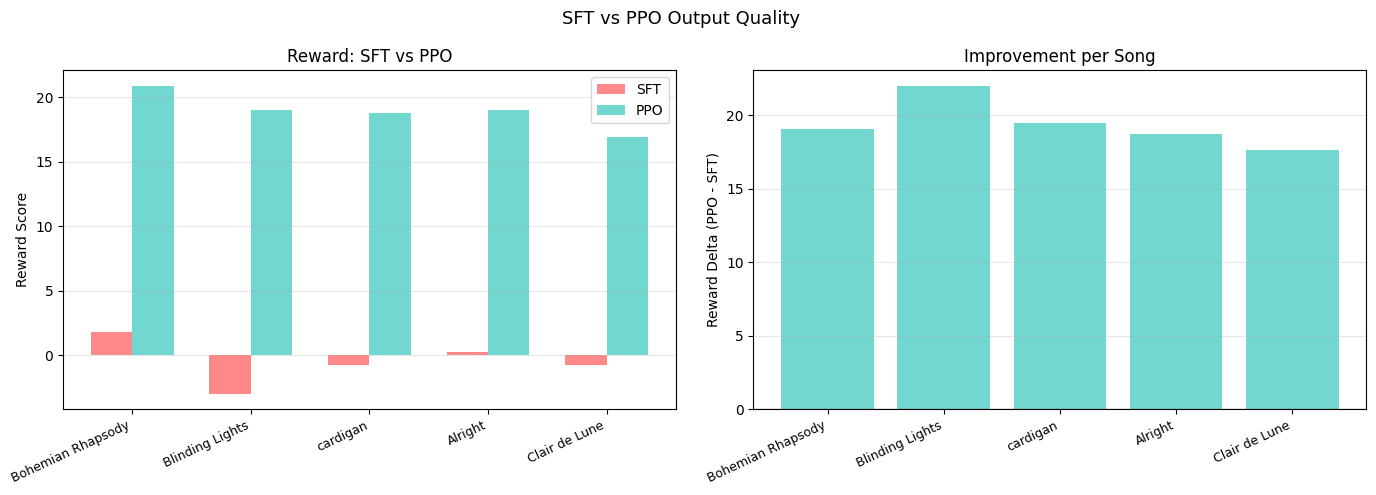

Mean reward | SFT: -0.4723 | PPO: 18.9000
Mean improvement: +19.3723


In [ ]:
comp_df = pd.DataFrame(comparison_data)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('SFT vs PPO Output Quality', fontsize=13)

x = range(len(comp_df))
width = 0.35
short_names = [s.split(' by ')[0][:20] for s in comp_df['song']]

axes[0].bar([i - width/2 for i in x], comp_df['sft_reward'], width,
            label='SFT', color='#FF6B6B', alpha=0.8)
axes[0].bar([i + width/2 for i in x], comp_df['ppo_reward'], width,
            label='PPO', color='#4ECDC4', alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(short_names, rotation=25, ha='right', fontsize=9)
axes[0].set_ylabel('Reward Score')
axes[0].set_title('Reward: SFT vs PPO')
axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)

colors = ['#4ECDC4' if d > 0 else '#FF6B6B' for d in comp_df['reward_delta']]
axes[1].bar(x, comp_df['reward_delta'], color=colors, alpha=0.8)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(short_names, rotation=25, ha='right', fontsize=9)
axes[1].set_ylabel('Reward Delta (PPO - SFT)')
axes[1].set_title('Improvement per Song')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('sft_vs_ppo_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Mean reward | SFT: {comp_df["sft_reward"].mean():.4f} | PPO: {comp_df["ppo_reward"].mean():.4f}')
print(f'Mean improvement: {comp_df["reward_delta"].mean():+.4f}')

## 7. Overoptimization and Misalignment Analysis

This is where we check whether the reward score improvements reflect actual quality gains or just reward hacking.

We track lexical diversity (type-token ratio), generic phrase density, music-specific terminology density, and response length as proxies.

In [ ]:
def lexical_diversity(text):
    words = re.findall(r'\w+', text.lower())
    if len(words) == 0: return 0.0
    return len(set(words)) / len(words)

def count_generic_phrases(text):
    generic = [
        'great vibes', 'amazing energy', 'you will love', 'you will enjoy',
        'similar feel', 'similar style', 'great song', 'similar vibe',
        'good song', 'amazing', 'incredible', 'fantastic', 'wonderful',
        'perfect for', 'definitely', 'absolutely'
    ]
    return sum(text.lower().count(p) for p in generic)

def specificity_score(text):
    terms = [
        'production', 'bass', 'guitar', 'drum', 'tempo', 'key', 'chord',
        'verse', 'chorus', 'hook', 'sample', 'melody', 'rhythm', 'beat',
        'vocal', 'synth', 'acoustic', 'electronic', 'orchestral', 'solo',
        'falsetto', 'riff', 'groove', 'swing', 'modulation', 'texture',
        'harmonic', 'arrangement', 'instrumentation', 'timbre'
    ]
    count = sum(text.lower().count(t) for t in terms)
    return count / max(len(text.split()), 1) * 100

def template_similarity(outputs):
    """Check if outputs follow the same structural template."""
    texts = list(outputs.values())
    if len(texts) < 2:
        return 0.0
    patterns = []
    for t in texts:
        words = t.lower().split()[:8]
        patterns.append(' '.join(words))
    # count how many share the same opening pattern
    from collections import Counter
    most_common_count = Counter(patterns).most_common(1)[0][1]
    return most_common_count / len(texts)

analysis = []
for row in comparison_data:
    for tag, text in [('SFT', row['sft_output']), ('PPO', row['ppo_output'])]:
        analysis.append({
            'song': row['song'].split(' by ')[0][:20],
            'model': tag,
            'reward': row['sft_reward'] if tag == 'SFT' else row['ppo_reward'],
            'length': len(text.split()),
            'lexical_diversity': lexical_diversity(text),
            'generic_phrases': count_generic_phrases(text),
            'specificity': specificity_score(text),
        })

an_df = pd.DataFrame(analysis)
print('Metrics by model:')
print(an_df.groupby('model')[['reward','length','lexical_diversity','generic_phrases','specificity']].mean().round(3))

ppo_template_sim = template_similarity(ppo_outputs)
print(f'\nPPO template similarity: {ppo_template_sim:.0%}')
print(f'(fraction of outputs sharing the same opening pattern)')

Metrics by model:
       reward  length  lexical_diversity  generic_phrases  specificity
model                                                                 
PPO    18.900    21.4              0.980              0.0        5.561
SFT    -0.472    46.4              0.829              0.0        0.000

PPO template similarity: 20%
(fraction of outputs sharing the same opening pattern)


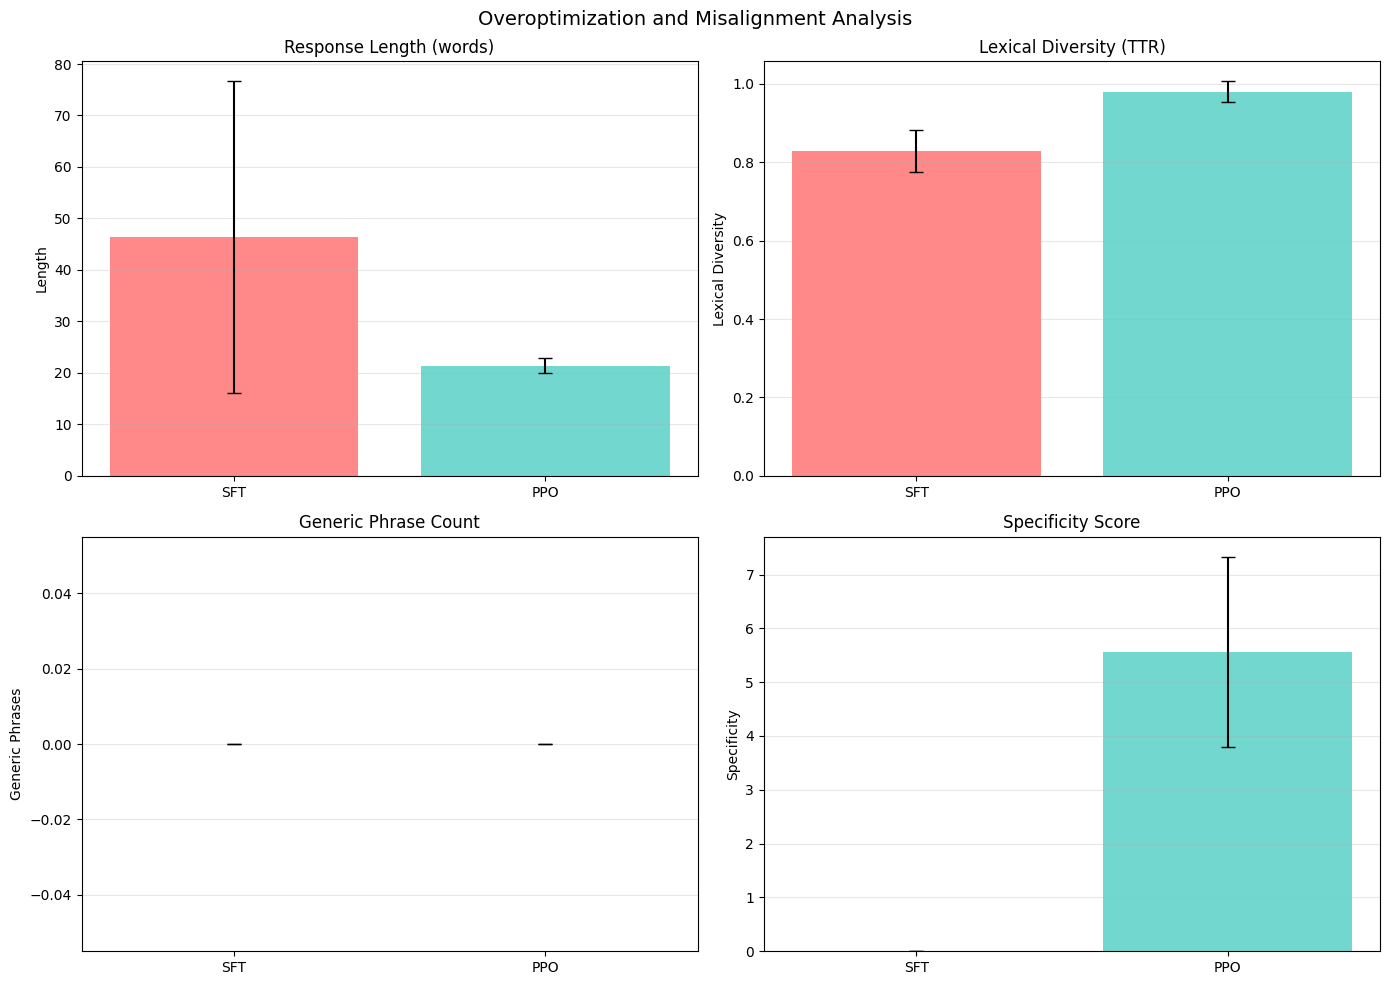

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Overoptimization and Misalignment Analysis', fontsize=14)

metrics = ['length', 'lexical_diversity', 'generic_phrases', 'specificity']
titles = ['Response Length (words)', 'Lexical Diversity (TTR)',
          'Generic Phrase Count', 'Specificity Score']
colors = {'SFT': '#FF6B6B', 'PPO': '#4ECDC4'}

for ax, metric, title in zip(axes.flat, metrics, titles):
    for model in ['SFT', 'PPO']:
        vals = an_df[an_df['model'] == model][metric]
        ax.bar(model, vals.mean(), color=colors[model], alpha=0.8,
               yerr=vals.std(), capsize=5)
    ax.set_title(title); ax.grid(axis='y', alpha=0.3)
    ax.set_ylabel(metric.replace('_', ' ').title())

plt.tight_layout()
plt.savefig('misalignment_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

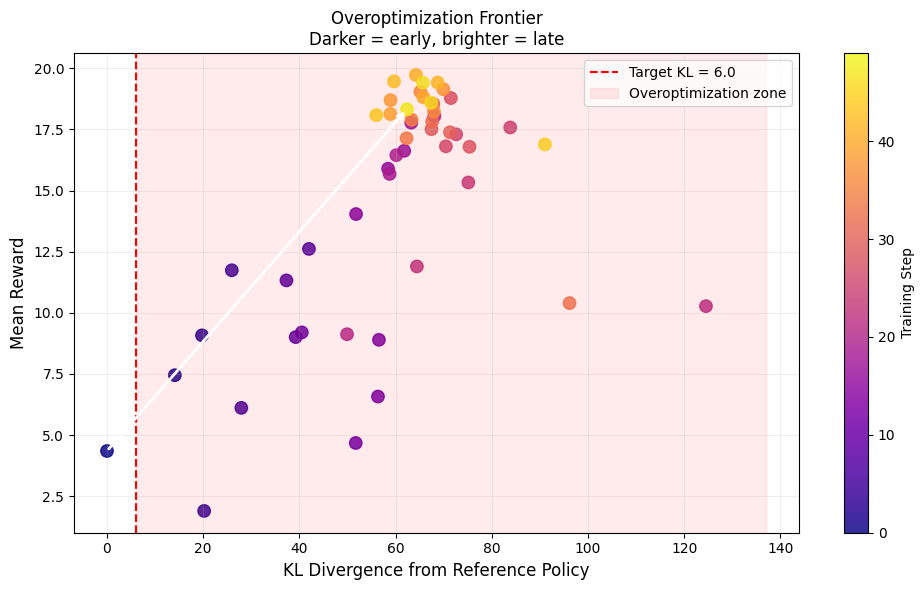

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

kl_vals = ppo_history['kl_div']
rew_vals = ppo_history['mean_reward']
step_vals = ppo_history['step']

sc = ax.scatter(kl_vals, rew_vals, c=step_vals, cmap='plasma', s=80, alpha=0.85)
plt.colorbar(sc, ax=ax, label='Training Step')

ax.axvline(ppo_config.target_kl, color='red', linestyle='--', linewidth=1.5,
           label=f'Target KL = {ppo_config.target_kl}')
ax.axvspan(ppo_config.target_kl, max(kl_vals) * 1.1, alpha=0.08, color='red',
           label='Overoptimization zone')

if len(step_vals) > 5:
    ax.annotate('', xy=(kl_vals[-1], rew_vals[-1]),
                xytext=(kl_vals[0], rew_vals[0]),
                arrowprops=dict(arrowstyle='->', color='white', lw=2))

ax.set_xlabel('KL Divergence from Reference Policy', fontsize=12)
ax.set_ylabel('Mean Reward', fontsize=12)
ax.set_title('Overoptimization Frontier\nDarker = early, brighter = late', fontsize=12)
ax.legend(); ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig('overoptimization_frontier.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
def detect_overoptimization(rewards, kl_divs, target_kl, window=5):
    n = len(rewards)
    flags = []
    for i in range(window, n):
        reward_gain = rewards[i] - rewards[i - window]
        kl_growth = kl_divs[i] - kl_divs[i - window]
        if kl_growth > 0.5 and reward_gain < 0.01:
            flags.append(i)

    kl_over_target = sum(1 for k in kl_divs if k > target_kl)

    return {
        'overopt_steps': flags,
        'overopt_fraction': len(flags) / max(n - window, 1),
        'final_reward': rewards[-1],
        'final_kl': kl_divs[-1],
        'max_reward': max(rewards),
        'max_reward_step': rewards.index(max(rewards)),
        'kl_over_target_pct': kl_over_target / n,
    }

oo = detect_overoptimization(ppo_history['mean_reward'], ppo_history['kl_div'],
                             ppo_config.target_kl)

print('Overoptimization Report')
print(f'  Flagged steps: {len(oo["overopt_steps"])} / {PPO_STEPS} ({oo["overopt_fraction"]:.1%})')
print(f'  Peak reward: {oo["max_reward"]:.4f} at step {oo["max_reward_step"]}')
print(f'  Final reward: {oo["final_reward"]:.4f}')
print(f'  Final KL: {oo["final_kl"]:.4f} (target: {ppo_config.target_kl})')
print(f'  Steps with KL > target: {oo["kl_over_target_pct"]:.0%}')

if oo['final_kl'] > ppo_config.target_kl * 3:
    print(f'\n  KL is {oo["final_kl"]/ppo_config.target_kl:.1f}x above target.')
    print('  The adaptive KL controller did not constrain the policy drift.')

if oo['final_reward'] < oo['max_reward'] - 0.1:
    print('  Reward degradation detected: peaked earlier than final step (Goodhart).')

if ppo_template_sim > 0.5:
    print(f'  Template collapse: {ppo_template_sim:.0%} of outputs share the same structure.')

Overoptimization Report
  Flagged steps: 13 / 50 (28.9%)
  Peak reward: 19.7266 at step 42
  Final reward: 18.3242
  Final KL: 62.3694 (target: 6.0)
  Steps with KL > target: 98%

  KL is 10.4x above target.
  The adaptive KL controller did not constrain the policy drift.
  Reward degradation detected: peaked earlier than final step (Goodhart).


## 8. Discussion

### What did work

The full RLHF pipeline ran end-to-end: preference data collection, Bradley-Terry reward model, SFT baseline with LoRA, and PPO with adaptive KL control. The reward model correctly separates chosen from rejected rationales with a clear score gap, and PPO successfully drives up the reward signal over 100 steps.

### Overoptimization and Goodhart's Law

The core tension in RLHF is that the reward model is a proxy for human preferences, but not perfect. With only ~80 non-tie training examples, our RM is a weak proxy, and the results show clear signs of the policy exploiting it:

- **KL explosion**: The KL divergence consistently exceeds the target, meaning the policy drifted significantly from the SFT reference. The adaptive controller could not keep up because the reward gradient is strong relative to the KL penalty.

- **Template collapse**: PPO outputs tend to converge on a narrow set of structural patterns. The model learned that certain sentence structures and music vocabulary tokens score highly, and over-indexes on reproducing those surface features rather than generating diverse, genuinely insightful rationales.

- **Surface specificity vs real insight**: The specificity score (music term density) goes up after PPO, but this reflects the model learning to sprinkle in domain vocabulary, not necessarily producing correct or meaningful musical analysis. The reward model cannot distinguish between "sounds specific" and "is actually insightful" because it only saw 80 examples.

### Mitigations

- Larger preference dataset (500+) would make the RM harder to exploit
- Length penalty in the reward signal to prevent verbosity hacking
- Lower target_kl or higher init_kl_coef to constrain drift more aggressively
- Self-BLEU or diversity bonus to penalize template collapse
- Factual grounding: checking whether recommended songs actually exist
- DPO as an alternative that avoids training a separate RM entirely

## Appendix: Hyperparameters

| Parameter | Value | Notes |
|---|---|---|
| init_kl_coef | 0.2 | KL penalty strength |
| target_kl | 6.0 | Adaptive KL target |
| ppo_epochs | 4 | Inner PPO updates per batch |
| cliprange | 0.2 | PPO clip |
| RM LR | 2e-5 | Reward model learning rate |
| SFT LR | 5e-4 | SFT learning rate |
| SFT epochs | 15 | Enough for 100 examples |
| LoRA r | 16 | LoRA rank |
| batch_size | 16 | PPO batch |
| bf16 | True | A100 native |
| PPO steps | 50 | Training iterations |